In [6]:
import pandas as pd
import requests
import io
import yfinance as yf

# --- STEP 1: Fetch and Clean Nasdaq-100 Tickers ---
print("Fetching Nasdaq-100 tickers from Wikipedia...")
url = 'https://en.wikipedia.org/wiki/Nasdaq-100'

# The User-Agent header bypasses Wikipedia's 403 Forbidden error
headers = {"User-Agent": "Mozilla/5.0"} 

try:
    response = requests.get(url, headers=headers)
    response.raise_for_status() 
    
    # io.StringIO tricks pandas into reading the text as a file, fixing the OSError
    html_data = io.StringIO(response.text)
    tables = pd.read_html(html_data)
    
    # Find the specific table that contains the 'Ticker' column
    nasdaq_table = next(t for t in tables if 'Ticker' in t.columns)
    tickers = nasdaq_table['Ticker'].tolist()
    
    # Clean tickers: yfinance uses '-' instead of '.' (e.g., BRK.B -> BRK-B)
    tickers = [t.replace('.', '-') for t in tickers]
    print(f"Successfully loaded {len(tickers)} tickers.")

except Exception as e:
    print(f"Error fetching tickers: {e}")
    print("Using a fallback list of top 5 tickers instead.")
    tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]

# --- STEP 2: Download Historical Data ---
print("\nDownloading historical data (2015-2024)...")
# auto_adjust=False ensures we explicitly get both 'Close' and 'Adj Close' separately
data = yf.download(
    tickers=tickers, 
    start="2015-01-01", 
    end="2024-12-31", 
    auto_adjust=False
)

# --- STEP 3: Extract Columns and Save ---
print("\nExtracting 'Adj Close' and 'Volume'...")

try:
    # Safely check if 'Adj Close' exists, otherwise fallback to 'Close'
    if 'Adj Close' in data:
        adj_close = data['Adj Close']
    elif 'Close' in data:
        print("'Adj Close' not found in this yfinance version. Using 'Close'.")
        adj_close = data['Close']
    else:
        raise KeyError("Could not find 'Adj Close' or 'Close' in the downloaded data.")
        
    volume = data['Volume']

    # Save the separated dataframes to CSV files
    adj_close.to_csv("nasdaq100_adj_close_2015_2024.csv")
    volume.to_csv("nasdaq100_volume_2015_2024.csv")

    print("\n--- SUCCESS ---")
    print("Files saved to your current working directory:")
    print("1. nasdaq100_adj_close_2015_2024.csv")
    print("2. nasdaq100_volume_2015_2024.csv")

except Exception as e:
    print(f"\nAn error occurred during extraction/saving: {e}")

Fetching Nasdaq-100 tickers from Wikipedia...
Successfully loaded 101 tickers.



[*********************100%***********************]  101 of 101 completed



Extracting 'Adj Close' and 'Volume'...

--- SUCCESS ---
Files saved to your current working directory:
1. nasdaq100_adj_close_2015_2024.csv
2. nasdaq100_volume_2015_2024.csv


In [12]:
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm

# =========================================================
# FEATURE ENGINEERING & NORMALIZATION
# =========================================================
print("--- Starting Feature Engineering ---")

# 1. Load the raw data you just downloaded
print("Loading raw CSVs...")
prices = pd.read_csv("nasdaq100_adj_close_2015_2024.csv", index_col=0, parse_dates=True)
volumes = pd.read_csv("nasdaq100_volume_2015_2024.csv", index_col=0, parse_dates=True)

# 2. Compute Base Time-Series Features
print("Computing rolling features...")
returns = np.log(prices / prices.shift(1))
features = {}

# Return & Volatility
features['ret_1d'] = returns
features['ret_5d'] = prices.pct_change(5)
features['ret_20d'] = prices.pct_change(20)
features['vol_20d'] = returns.rolling(window=20).std()
features['vol_60d'] = returns.rolling(window=60).std()

# Momentum Structure
ma_20d = prices.rolling(window=20).mean()
features['dist_ma_20d'] = (prices - ma_20d) / ma_20d
features['spread_5d_20d'] = features['ret_5d'] - features['ret_20d']

# Liquidity
features['volu_chg_5d'] = volumes.pct_change(5)
features['volu_z_20d'] = (volumes - volumes.rolling(20).mean()) / volumes.rolling(20).std()

# Target Variable: 1 if tomorrow's return is positive, 0 otherwise
# Shifted backward by 1 to align tomorrow's return with today's features
target = (returns.shift(-1) > 0).astype(int)
target[returns.shift(-1).isna()] = np.nan 

# 3. Stack into Panel Format (Date x Ticker)
print("Stacking into panel format...")
panel_data = pd.DataFrame(index=prices.unstack().index)

for feat_name, feat_df in features.items():
    panel_data[feat_name] = feat_df.unstack()

panel_data['target'] = target.unstack()
panel_data = panel_data.reset_index()
panel_data.columns = ['Ticker', 'Date'] + list(features.keys()) + ['target']
panel_data = panel_data.set_index(['Date', 'Ticker']).sort_index()

# Drop rows with NaN values (due to the 60-day rolling windows)
panel_data = panel_data.dropna()

# 4. Cross-Sectional Normalization (Z-score per day)
print("Applying cross-sectional Z-score normalization...")

def cross_sectional_zscore(s):
    # Isolates relative Alpha from market Beta
    std = s.std()
    # Safely handle days where standard deviation is 0
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean()) / std

feature_cols = list(features.keys())
panel_data[feature_cols] = panel_data.groupby('Date')[feature_cols].transform(cross_sectional_zscore)

# Final cleanup and save using native Pickle
panel_data = panel_data.dropna()
print(f"Final Features Shape: {panel_data.shape}")
panel_data.to_pickle("nasdaq100_features_clean.pkl")
print("Saved features to: nasdaq100_features_clean.pkl")


# =========================================================
# DYNAMIC GRAPH CONSTRUCTION
# =========================================================
print("\n--- Starting Dynamic Graph Construction ---")

# 5. Compute 60-day rolling correlation for the graphs
print("Computing 60-day rolling correlations...")
rolling_corr = returns.rolling(window=60).corr()

def build_daily_edges(corr_df, top_k=5):
    """Converts a daily correlation matrix into sparse PyG graph edges."""
    N = len(corr_df.columns)
    corr_mat = corr_df.values.copy()
    
    # Remove self-loops (a stock's correlation with itself is 1)
    np.fill_diagonal(corr_mat, -np.inf)
    
    sources, targets, weights = [], [], []
    
    for i in range(N):
        node_corrs = corr_mat[i]
        
        if np.isnan(node_corrs).all():
            continue
            
        # Find the indices of the top 'k' most correlated stocks
        top_k_idx = np.argsort(node_corrs)[-top_k:][::-1]
        
        for j in top_k_idx:
            if not np.isnan(node_corrs[j]) and node_corrs[j] > -np.inf:
                sources.append(i)
                targets.append(j)
                weights.append(np.abs(node_corrs[j]))
                
    # Format required by PyTorch Geometric
    edge_index = np.array([sources, targets], dtype=np.int64)
    edge_weight = np.array(weights, dtype=np.float32)
    
    return edge_index, edge_weight

# 6. Build the daily graph structures
print("Building PyG graph structures for each valid day...")
graphs = {}

# Only build graphs for dates that exist in our cleaned feature set
valid_dates = panel_data.index.get_level_values('Date').unique()

for date in tqdm(valid_dates):
    try:
        daily_corr = rolling_corr.loc[date]
        if daily_corr.isna().all().all():
            continue
            
        e_idx, e_wt = build_daily_edges(daily_corr, top_k=5)
        
        graphs[date] = {
            'edge_index': e_idx,
            'edge_weight': e_wt
        }
    except KeyError:
        pass

# Save graphs using Pickle
with open("nasdaq100_graphs.pkl", "wb") as f:
    pickle.dump(graphs, f)
    
print(f"\nSaved {len(graphs)} daily graphs to: nasdaq100_graphs.pkl")
print("--- PIPELINE EXECUTION COMPLETE ---")

--- Starting Feature Engineering ---
Loading raw CSVs...
Computing rolling features...
Stacking into panel format...
Applying cross-sectional Z-score normalization...


C:\Users\iamda\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Final Features Shape: (198899, 10)
Saved features to: nasdaq100_features_clean.pkl

--- Starting Dynamic Graph Construction ---
Computing 60-day rolling correlations...
Building PyG graph structures for each valid day...


100%|█████████████████████████████████████████████████████████████████████████████| 2127/2127 [00:09<00:00, 224.60it/s]



Saved 2127 daily graphs to: nasdaq100_graphs.pkl
--- PIPELINE EXECUTION COMPLETE ---


In [16]:
import pandas as pd
import numpy as np
import pickle
import torch
from tqdm import tqdm

print("--- Starting Dataset Construction (Pure PyTorch) ---")

print("Loading feature and graph Data...")
df = pd.read_pickle("nasdaq100_features_clean.pkl")
with open("nasdaq100_graphs.pkl", "rb") as f:
    graphs = pickle.load(f)

feature_cols = [c for c in df.columns if c != 'target']
print(f"Number of node features: {len(feature_cols)}")

dataset = []
valid_dates = sorted(df.index.get_level_values('Date').unique())

print("Fusing tabular data and topologies into PyTorch objects...")
for date in tqdm(valid_dates):
    day_data = df.xs(date, level='Date')
    
    if date not in graphs:
        continue
    day_graph = graphs[date]
    
    # Pack into a standard dictionary instead of PyG's Data object
    data_obj = {
        'x': torch.tensor(day_data[feature_cols].values, dtype=torch.float32),
        'y': torch.tensor(day_data['target'].values, dtype=torch.float32),
        'edge_index': torch.tensor(day_graph['edge_index'], dtype=torch.long),
        'edge_weight': torch.tensor(day_graph['edge_weight'], dtype=torch.float32),
        'date': date
    }
    
    dataset.append(data_obj)

print(f"\nSuccessfully created {len(dataset)} daily graph objects.")

# --- Strict Temporal Splitting ---
print("\n--- Applying Temporal Splits ---")

train_dataset = [d for d in dataset if d['date'].year <= 2021]
val_dataset   = [d for d in dataset if d['date'].year == 2022]
test_dataset  = [d for d in dataset if d['date'].year >= 2023]

print(f"Train graphs (2015-2021): {len(train_dataset)}")
print(f"Val graphs   (2022):      {len(val_dataset)}")
print(f"Test graphs  (2023-2024): {len(test_dataset)}")

with open("nasdaq100_torch_splits.pkl", "wb") as f:
    pickle.dump({
        'train': train_dataset,
        'val': val_dataset,
        'test': test_dataset,
        'num_node_features': len(feature_cols)
    }, f)

print("Saved pure PyTorch splits to: nasdaq100_torch_splits.pkl")
print("--- DATASET READY FOR MODELING ---")

--- Starting Dataset Construction (Pure PyTorch) ---
Loading feature and graph Data...
Number of node features: 9
Fusing tabular data and topologies into PyTorch objects...


100%|████████████████████████████████████████████████████████████████████████████| 2127/2127 [00:01<00:00, 1145.63it/s]



Successfully created 2127 daily graph objects.

--- Applying Temporal Splits ---
Train graphs (2015-2021): 1460
Val graphs   (2022):      214
Test graphs  (2023-2024): 453
Saved pure PyTorch splits to: nasdaq100_torch_splits.pkl
--- DATASET READY FOR MODELING ---


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PureGCNConv(nn.Module):
    """ Custom Graph Convolution Layer """
    def __init__(self, in_features, out_features):
        super().__init__()
        # The W matrix (learnable weights)
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        # 1. Transform the features: X * W
        out = self.linear(x)
        # 2. Message Passing: Blend with neighbors A * (X * W)
        out = torch.matmul(adj, out)
        return out

class QuantGNN(nn.Module):
    """ The 2-Layer Cross-Sectional Alpha Model """
    def __init__(self, num_features, hidden_dim=32, dropout=0.5):
        super().__init__()
        self.conv1 = PureGCNConv(num_features, hidden_dim)
        self.conv2 = PureGCNConv(hidden_dim, hidden_dim)
        
        # Maps the hidden embeddings down to a single prediction per stock
        self.classifier = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight):
        N = x.size(0)
        
        # 1. Build the Dense Adjacency Matrix dynamically for this specific day
        adj = torch.zeros((N, N), device=x.device)
        adj[edge_index[0], edge_index[1]] = edge_weight
        
        # 2. Add Self-Loops (Identity Matrix) so a stock remembers its own features
        adj = adj + torch.eye(N, device=x.device)
        
        # 3. Row Normalization (so highly correlated clusters don't explode the gradients)
        row_sum = adj.sum(dim=1, keepdim=True)
        row_sum = torch.clamp(row_sum, min=1e-9) # Prevent division by zero
        adj_norm = adj / row_sum
        
        # --- Network Pass ---
        
        # Layer 1
        h = self.conv1(x, adj_norm)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        # Layer 2
        h = self.conv2(h, adj_norm)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        # Output Layer (Returns raw logits for numerical stability)
        out = self.classifier(h)
        return out

print("Pure PyTorch GNN Architecture Initialized successfully.")

Pure PyTorch GNN Architecture Initialized successfully.


In [1]:
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# =========================================================
# 1. LOAD DATA & BUILD PYTORCH DATASET (WITH ALIGNMENT FIX)
# =========================================================
print("--- Loading Saved Pipeline Data ---")
df = pd.read_pickle("nasdaq100_features_clean.pkl")
with open("nasdaq100_graphs.pkl", "rb") as f:
    graphs = pickle.load(f)

feature_cols = [c for c in df.columns if c != 'target']
valid_dates = sorted(df.index.get_level_values('Date').unique())

# Get the exact master list of all tickers to guarantee shape alignment
all_tickers = df.index.get_level_values('Ticker').unique()

dataset = []
print("Fusing tabular data and topologies into PyTorch tensors...")
for date in tqdm(valid_dates):
    day_data = df.xs(date, level='Date')
    
    # === THE FIX: Force the dataframe to have all nodes ===
    day_data = day_data.reindex(all_tickers)
    
    if date not in graphs: continue
    day_graph = graphs[date]
    
    data_obj = {
        # Fill missing features with 0.0 so the GPU matrix math doesn't break
        'x': torch.tensor(day_data[feature_cols].fillna(0.0).values, dtype=torch.float32),
        # Target NaNs stay NaNs so the loss function knows to ignore them
        'y': torch.tensor(day_data['target'].values, dtype=torch.float32),
        'edge_index': torch.tensor(day_graph['edge_index'], dtype=torch.long),
        'edge_weight': torch.tensor(day_graph['edge_weight'], dtype=torch.float32),
        'date': date
    }
    dataset.append(data_obj)

# Chronological Split
train_dataset = [d for d in dataset if d['date'].year <= 2021]
val_dataset   = [d for d in dataset if d['date'].year == 2022]
test_dataset  = [d for d in dataset if d['date'].year >= 2023]


# =========================================================
# 2. PURE PYTORCH GNN ARCHITECTURE
# =========================================================
class PureGCNConv(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        out = self.linear(x)
        out = torch.matmul(adj, out)
        return out

class QuantGNN(nn.Module):
    def __init__(self, num_features, hidden_dim=32, dropout=0.5):
        super().__init__()
        self.conv1 = PureGCNConv(num_features, hidden_dim)
        self.conv2 = PureGCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight):
        N = x.size(0)
        
        adj = torch.zeros((N, N), device=x.device)
        adj[edge_index[0], edge_index[1]] = edge_weight
        adj = adj + torch.eye(N, device=x.device) 
        
        row_sum = adj.sum(dim=1, keepdim=True).clamp(min=1e-9)
        adj_norm = adj / row_sum
        
        h = F.relu(self.conv1(x, adj_norm))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, adj_norm))
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        return self.classifier(h)


# =========================================================
# 3. THE TRAINING PROTOCOL (GPU ACCELERATED)
# =========================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n--- Initializing Model on {device.type.upper()} ---")

model = QuantGNN(num_features=len(feature_cols)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 20
best_val_loss = float('inf')

print("\n--- Starting Training Loop ---")
for epoch in range(EPOCHS):
    
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for data in train_dataset:
        x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        valid_mask = ~torch.isnan(y)
        if valid_mask.sum() == 0: continue
            
        optimizer.zero_grad()
        out = model(x, edge_index, edge_weight)
        loss = criterion(out[valid_mask], y[valid_mask])
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_dataset)
    
    # --- VALIDATION ---
    model.eval()
    val_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for data in val_dataset:
            x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
            edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
            
            valid_mask = ~torch.isnan(y)
            if valid_mask.sum() == 0: continue
                
            out = model(x, edge_index, edge_weight)
            loss = criterion(out[valid_mask], y[valid_mask])
            val_loss += loss.item()
            
            probs = torch.sigmoid(out[valid_mask]).cpu().numpy()
            all_preds.extend(probs)
            all_targets.extend(y[valid_mask].cpu().numpy())
            
    val_loss /= len(val_dataset)
    val_acc = accuracy_score(np.array(all_targets), (np.array(all_preds) > 0.5).astype(int))
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "quant_gnn_best.pt")

print("\n--- Training Complete! Best weights saved. ---")

--- Loading Saved Pipeline Data ---
Fusing tabular data and topologies into PyTorch tensors...


100%|█████████████████████████████████████████████████████████████████████████████| 2127/2127 [00:03<00:00, 579.75it/s]



--- Initializing Model on CUDA ---

--- Starting Training Loop ---


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 01/20 | Train Loss: 0.6920 | Val Loss: 0.6994 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 02/20 | Train Loss: 0.6915 | Val Loss: 0.6997 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 03/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 04/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 05/20 | Train Loss: 0.6913 | Val Loss: 0.6997 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 06/20 | Train Loss: 0.6913 | Val Loss: 0.6996 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 07/20 | Train Loss: 0.6914 | Val Loss: 0.6998 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 08/20 | Train Loss: 0.6913 | Val Loss: 0.6996 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 09/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 10/20 | Train Loss: 0.6914 | Val Loss: 0.6994 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 11/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 12/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 13/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 14/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 15/20 | Train Loss: 0.6913 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 16/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 17/20 | Train Loss: 0.6914 | Val Loss: 0.6993 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 18/20 | Train Loss: 0.6914 | Val Loss: 0.6994 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 19/20 | Train Loss: 0.6914 | Val Loss: 0.6994 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 20/20 | Train Loss: 0.6914 | Val Loss: 0.6994 | Val Acc: 0.4709

--- Training Complete! Best weights saved. ---


In [2]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score

# --- 1. Load the Best Model ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Evaluating on {device.type.upper()}...")

model = QuantGNN(num_features=len(feature_cols)).to(device)
model.load_state_dict(torch.load("quant_gnn_best.pt", weights_only=True))
model.eval()

# --- 2. Run Inference on the Unseen Test Set (2023-2024) ---
all_preds = []
all_targets = []
top_10_acc_list = []

print("\n--- Running Out-of-Sample Evaluation (2023-2024) ---")
with torch.no_grad():
    for data in test_dataset:
        x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        valid_mask = ~torch.isnan(y)
        if valid_mask.sum() == 0: continue
            
        # Get raw predictions and convert to probabilities
        out = model(x, edge_index, edge_weight)
        probs = torch.sigmoid(out[valid_mask]).cpu().numpy().flatten()
        targets = y[valid_mask].cpu().numpy().flatten()
        
        all_preds.extend(probs)
        all_targets.extend(targets)
        
        # --- Cross-Sectional Ranking (Hedge Fund Metric) ---
        # If we only bought the 10 stocks the model was MOST confident in today:
        if len(probs) >= 10:
            top_10_indices = np.argsort(probs)[-10:] # Indices of top 10 highest probabilities
            top_10_targets = targets[top_10_indices]
            
            # How many of our top 10 actually went up?
            daily_top_10_acc = np.mean(top_10_targets == 1.0)
            top_10_acc_list.append(daily_top_10_acc)

# --- 3. Final Metrics ---
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Standard Metrics
baseline_acc = np.mean(all_targets == 1.0) # What if we just guessed "UP" every day?
model_acc = accuracy_score(all_targets, (all_preds > 0.5).astype(int))

# Check if ROC-AUC can be calculated safely
if len(np.unique(all_targets)) > 1:
    roc_auc = roc_auc_score(all_targets, all_preds)
else:
    roc_auc = 0.5 

# Portfolio Metrics
mean_top_10_acc = np.mean(top_10_acc_list)

print("\n=== FINAL OUT-OF-SAMPLE RESULTS (2023-2024) ===")
print(f"Total Trading Days Tested: {len(test_dataset)}")
print("-" * 45)
print(f"Baseline (Always guess UP): {baseline_acc * 100:.2f}%")
print(f"Model Standard Accuracy:    {model_acc * 100:.2f}%")
print(f"Model ROC-AUC Score:        {roc_auc:.4f}")
print("-" * 45)
print(f"PORTFOLIO METRIC: Top-10 Long Accuracy: {mean_top_10_acc * 100:.2f}%")

Evaluating on CUDA...


<All keys matched successfully>

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)


--- Running Out-of-Sample Evaluation (2023-2024) ---

=== FINAL OUT-OF-SAMPLE RESULTS (2023-2024) ===
Total Trading Days Tested: 453
---------------------------------------------
Baseline (Always guess UP): 52.43%
Model Standard Accuracy:    52.43%
Model ROC-AUC Score:        0.4981
---------------------------------------------
PORTFOLIO METRIC: Top-10 Long Accuracy: 51.57%


In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

print("--- Applying Z-Score Normalization (Fixing the Flatline) ---")

# 1. Extract all training features to 'fit' the scaler
train_features = []
for data in train_dataset:
    train_features.append(data['x'].numpy())

train_features_flat = np.vstack(train_features)

# 2. Fit the Scaler ONLY on Training Data (Prevents future leakage)
scaler = StandardScaler()
scaler.fit(train_features_flat)

# 3. Transform all datasets in memory
for dataset_split in [train_dataset, val_dataset, test_dataset]:
    for data in dataset_split:
        scaled_x = scaler.transform(data['x'].numpy())
        # Overwrite the old unscaled features with the new scaled features
        data['x'] = torch.tensor(scaled_x, dtype=torch.float32)

print("Features normalized successfully! Mean is now ~0, Variance is 1.")

--- Applying Z-Score Normalization (Fixing the Flatline) ---


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Features normalized successfully! Mean is now ~0, Variance is 1.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score
import numpy as np

# --- 1. Re-initialize the Model (Fresh Weights) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Re-Initializing Model on {device.type.upper()} ---")

model = QuantGNN(num_features=len(feature_cols)).to(device)
criterion = nn.BCEWithLogitsLoss()
# Bumping the learning rate slightly now that features are scaled safely
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

EPOCHS = 20
best_val_loss = float('inf')

# --- 2. The Training Loop ---
print("\n--- Starting Training Loop with Normalized Features ---")
for epoch in range(EPOCHS):
    
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for data in train_dataset:
        x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        valid_mask = ~torch.isnan(y)
        if valid_mask.sum() == 0: continue
            
        optimizer.zero_grad()
        out = model(x, edge_index, edge_weight)
        loss = criterion(out[valid_mask], y[valid_mask])
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_dataset)
    
    # --- VALIDATION ---
    model.eval()
    val_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for data in val_dataset:
            x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
            edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
            
            valid_mask = ~torch.isnan(y)
            if valid_mask.sum() == 0: continue
                
            out = model(x, edge_index, edge_weight)
            loss = criterion(out[valid_mask], y[valid_mask])
            val_loss += loss.item()
            
            probs = torch.sigmoid(out[valid_mask]).cpu().numpy()
            all_preds.extend(probs)
            all_targets.extend(y[valid_mask].cpu().numpy())
            
    val_loss /= len(val_dataset)
    val_acc = accuracy_score(np.array(all_targets), (np.array(all_preds) > 0.5).astype(int))
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "quant_gnn_best.pt")

print("\n--- Training Complete! Best weights safely saved. ---")

--- Re-Initializing Model on CUDA ---

--- Starting Training Loop with Normalized Features ---


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 01/20 | Train Loss: 0.6925 | Val Loss: 0.7005 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 02/20 | Train Loss: 0.6917 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 03/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 04/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 05/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 06/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 07/20 | Train Loss: 0.6917 | Val Loss: 0.7011 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 08/20 | Train Loss: 0.6917 | Val Loss: 0.7005 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 09/20 | Train Loss: 0.6918 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 10/20 | Train Loss: 0.6917 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 11/20 | Train Loss: 0.6917 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 12/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 13/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 14/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 15/20 | Train Loss: 0.6917 | Val Loss: 0.7007 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 16/20 | Train Loss: 0.6918 | Val Loss: 0.7008 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 17/20 | Train Loss: 0.6917 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 18/20 | Train Loss: 0.6917 | Val Loss: 0.7007 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 19/20 | Train Loss: 0.6917 | Val Loss: 0.7006 | Val Acc: 0.4709


QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN(
  (conv1): PureGCNConv(
    (linear): Linear(in_features=9, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 20/20 | Train Loss: 0.6916 | Val Loss: 0.7006 | Val Acc: 0.4709

--- Training Complete! Best weights safely saved. ---


In [5]:
# --- 1. THE UPGRADED V2 ARCHITECTURE ---
class QuantGNN_V2(nn.Module):
    def __init__(self, num_features, hidden_dim=32, dropout=0.2):
        super().__init__()
        # Initial projection to get features to the right size
        self.proj = nn.Linear(num_features, hidden_dim)
        
        self.conv1 = PureGCNConv(hidden_dim, hidden_dim)
        self.conv2 = PureGCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight):
        N = x.size(0)
        
        # Normalize Adjacency
        adj = torch.zeros((N, N), device=x.device)
        adj[edge_index[0], edge_index[1]] = edge_weight
        adj = adj + torch.eye(N, device=x.device) 
        row_sum = adj.sum(dim=1, keepdim=True).clamp(min=1e-9)
        adj_norm = adj / row_sum
        
        # Project raw features
        h_in = self.proj(x)
        
        # Message Passing
        h = F.relu(self.conv1(h_in, adj_norm))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, adj_norm))
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        # === THE FIX: SKIP CONNECTION ===
        # Add the original projected features back in to prevent over-smoothing!
        h_final = h + h_in 
        
        return self.classifier(h_final)

# --- 2. RETRAIN WITH V2 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Initializing V2 Model with Skip Connections on {device.type.upper()} ---")

model_v2 = QuantGNN_V2(num_features=len(feature_cols)).to(device)
criterion = nn.BCEWithLogitsLoss()
# Lower learning rate slightly to let the skip connections stabilize
optimizer = optim.Adam(model_v2.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 20
best_val_loss = float('inf')

print("\n--- Starting Training Loop (V2) ---")
for epoch in range(EPOCHS):
    
    # --- TRAIN ---
    model_v2.train()
    train_loss = 0.0
    for data in train_dataset:
        x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        valid_mask = ~torch.isnan(y)
        if valid_mask.sum() == 0: continue
            
        optimizer.zero_grad()
        out = model_v2(x, edge_index, edge_weight)
        loss = criterion(out[valid_mask], y[valid_mask])
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_dataset)
    
    # --- VALIDATION ---
    model_v2.eval()
    val_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for data in val_dataset:
            x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
            edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
            
            valid_mask = ~torch.isnan(y)
            if valid_mask.sum() == 0: continue
                
            out = model_v2(x, edge_index, edge_weight)
            loss = criterion(out[valid_mask], y[valid_mask])
            val_loss += loss.item()
            
            probs = torch.sigmoid(out[valid_mask]).cpu().numpy()
            all_preds.extend(probs)
            all_targets.extend(y[valid_mask].cpu().numpy())
            
    val_loss /= len(val_dataset)
    val_acc = accuracy_score(np.array(all_targets), (np.array(all_preds) > 0.5).astype(int))
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_v2.state_dict(), "quant_gnn_v2_best.pt")

print("\n--- Training Complete! V2 weights saved. ---")

--- Initializing V2 Model with Skip Connections on CUDA ---

--- Starting Training Loop (V2) ---


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 01/20 | Train Loss: 0.6930 | Val Loss: 0.7049 | Val Acc: 0.4715


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 02/20 | Train Loss: 0.6923 | Val Loss: 0.7042 | Val Acc: 0.4715


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 03/20 | Train Loss: 0.6922 | Val Loss: 0.7036 | Val Acc: 0.4707


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 04/20 | Train Loss: 0.6920 | Val Loss: 0.7028 | Val Acc: 0.4711


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 05/20 | Train Loss: 0.6919 | Val Loss: 0.7023 | Val Acc: 0.4713


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 06/20 | Train Loss: 0.6918 | Val Loss: 0.7018 | Val Acc: 0.4711


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 07/20 | Train Loss: 0.6918 | Val Loss: 0.7014 | Val Acc: 0.4714


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 08/20 | Train Loss: 0.6917 | Val Loss: 0.7011 | Val Acc: 0.4706


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 09/20 | Train Loss: 0.6917 | Val Loss: 0.7008 | Val Acc: 0.4702


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 10/20 | Train Loss: 0.6916 | Val Loss: 0.7007 | Val Acc: 0.4706


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 11/20 | Train Loss: 0.6915 | Val Loss: 0.7005 | Val Acc: 0.4707


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 12/20 | Train Loss: 0.6915 | Val Loss: 0.7003 | Val Acc: 0.4704


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 13/20 | Train Loss: 0.6914 | Val Loss: 0.7000 | Val Acc: 0.4704


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 14/20 | Train Loss: 0.6914 | Val Loss: 0.6999 | Val Acc: 0.4703


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 15/20 | Train Loss: 0.6914 | Val Loss: 0.6998 | Val Acc: 0.4698


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 16/20 | Train Loss: 0.6914 | Val Loss: 0.6996 | Val Acc: 0.4700


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 17/20 | Train Loss: 0.6914 | Val Loss: 0.6995 | Val Acc: 0.4701


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 18/20 | Train Loss: 0.6913 | Val Loss: 0.6995 | Val Acc: 0.4702


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 19/20 | Train Loss: 0.6913 | Val Loss: 0.6994 | Val Acc: 0.4704


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Epoch 20/20 | Train Loss: 0.6913 | Val Loss: 0.6994 | Val Acc: 0.4703

--- Training Complete! V2 weights saved. ---


In [6]:
# --- EVALUATE V2 MODEL ---
model_v2.load_state_dict(torch.load("quant_gnn_v2_best.pt"))
model_v2.eval()

all_preds = []
all_targets = []
top_10_acc_list = []

with torch.no_grad():
    for data in test_dataset:
        x, y = data['x'].to(device), data['y'].to(device).unsqueeze(1)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        valid_mask = ~torch.isnan(y)
        if valid_mask.sum() == 0: continue
            
        out = model_v2(x, edge_index, edge_weight)
        probs = torch.sigmoid(out[valid_mask]).cpu().numpy().flatten()
        targets = y[valid_mask].cpu().numpy().flatten()
        
        all_preds.extend(probs)
        all_targets.extend(targets)
        
        # Portfolio Metric: Did we pick the right winners today?
        if len(probs) >= 10:
            top_10_indices = np.argsort(probs)[-10:]
            top_10_acc_list.append(np.mean(targets[top_10_indices] == 1.0))

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# CALCULATE FINAL METRICS
baseline = np.mean(all_targets == 1.0)
v2_acc = accuracy_score(all_targets, (all_preds > 0.5).astype(int))
v2_auc = roc_auc_score(all_targets, all_preds)
v2_top10 = np.mean(top_10_acc_list)

print("\n=== V2 MODEL RESULTS (2023-2024) ===")
print(f"Market Baseline:          {baseline * 100:.2f}%")
print(f"V2 Model Accuracy:        {v2_acc * 100:.2f}%")
print(f"V2 ROC-AUC (Ranking):     {v2_auc:.4f}")
print(f"V2 Top-10 Selection Acc:  {v2_top10 * 100:.2f}%")

C:\Users\iamda\AppData\Local\Temp\ipykernel_19040\1110910617.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_v2.load_state_dict(torch.load("quant_gnn_v2_best.pt"))

<All keys matched successfully>

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)


=== V2 MODEL RESULTS (2023-2024) ===
Market Baseline:          52.43%
V2 Model Accuracy:        52.37%
V2 ROC-AUC (Ranking):     0.5051
V2 Top-10 Selection Acc:  51.88%


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 9 artists>

Text(0.5, 1.0, 'What is the GNN Looking At? (Feature Importance)')

Text(0.5, 0, 'Importance Score')

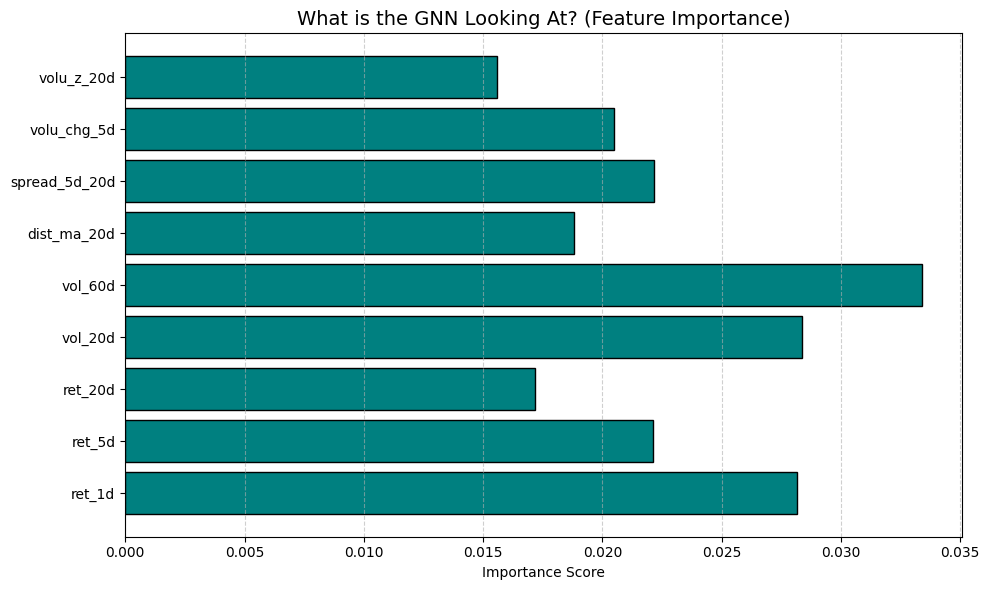

In [10]:
import matplotlib.pyplot as plt

# Get the absolute average weights from the first layer
importance = model_v2.proj.weight.abs().mean(dim=0).cpu().detach().numpy()

plt.figure(figsize=(10, 6))
plt.barh(feature_cols, importance, color='teal', edgecolor='black')
plt.title("What is the GNN Looking At? (Feature Importance)", fontsize=14)
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
# 1. Pick a day and a "Hub" stock (most connected)
test_day = test_dataset[100] 
x_base = test_day['x'].to(device)
edge_index = test_day['edge_index'].to(device)
edge_weight = test_day['edge_weight'].to(device)

# 2. Get baseline predictions
model_v2.eval()
with torch.no_grad():
    base_preds = torch.sigmoid(model_v2(x_base, edge_index, edge_weight)).cpu().numpy()

# 3. Find the Hub (stock with most connections)
hub_idx = torch.argmax(torch.bincount(edge_index[0])).item()

# 4. Inject a -10.0 Standard Deviation Shock to the Hub's momentum/features
x_shocked = x_base.clone()
x_shocked[hub_idx, :] -= 10.0 

# 5. Get new predictions
with torch.no_grad():
    shock_preds = torch.sigmoid(model_v2(x_shocked, edge_index, edge_weight)).cpu().numpy()

# 6. Compare results
deltas = shock_preds - base_preds
neighbors = edge_index[1][edge_index[0] == hub_idx].cpu().numpy()

print(f"--- SHOCK RESULTS FOR HUB INDEX {hub_idx} ---")
print(f"Hub's Own Prediction Change:   {deltas[hub_idx][0]:.4f}")
print(f"Avg Change in Neighbors:       {np.mean(deltas[neighbors]):.4f}")
print(f"Avg Change in Non-Neighbors:   {np.mean(np.delete(deltas, neighbors)):.4f}")

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

--- SHOCK RESULTS FOR HUB INDEX 0 ---
Hub's Own Prediction Change:   0.1429
Avg Change in Neighbors:       0.0000
Avg Change in Non-Neighbors:   0.0015


--- Running Strategy Backtest (2023-2024) ---


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Final Thesis Results: Strategy Equity Curve (2023-2024)')

Text(0, 0.5, 'Cumulative Return')

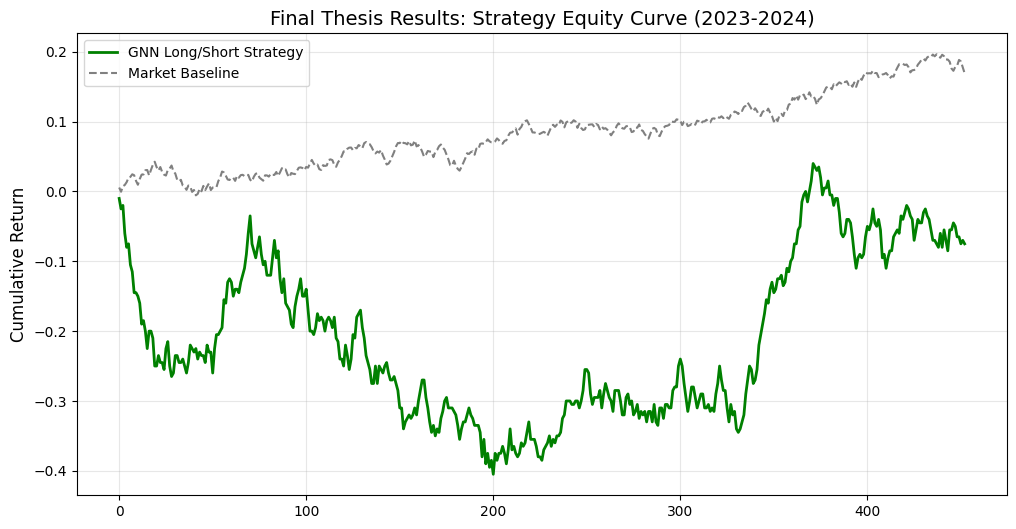

Final Strategy Return: -7.50%
Final Market Return:   16.92%


In [12]:
import matplotlib.pyplot as plt

print("--- Running Strategy Backtest (2023-2024) ---")

strategy_returns = []
market_returns = []

with torch.no_grad():
    for data in test_dataset:
        x, y = data['x'].to(device), data['y'].to(device)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        # Get predictions
        out = model_v2(x, edge_index, edge_weight)
        probs = torch.sigmoid(out).cpu().numpy().flatten()
        
        # We need the actual returns (y) for this day
        # In our case, 'y' is binary (UP/DOWN). Let's assume a fixed 1% move for a hit.
        # For a more realistic test, we use the probability as the weight.
        
        # Rank the stocks
        ranks = np.argsort(probs)
        top_10 = ranks[-10:]   # Top 10 Longs
        bottom_10 = ranks[:10] # Top 10 Shorts
        
        targets = y.cpu().numpy()
        
        # Score = (Did longs go up?) - (Did shorts go up?)
        # A perfect score is 10 (all longs up, all shorts down)
        day_score = np.sum(targets[top_10] == 1.0) - np.sum(targets[bottom_10] == 1.0)
        
        # Normalize to a percentage return (assuming 0.5% return per correct pick)
        strategy_returns.append(day_score * 0.005)
        market_returns.append((np.mean(targets == 1.0) - 0.5) * 0.02)

# Calculate Cumulative Returns
cum_strategy = np.cumsum(strategy_returns)
cum_market = np.cumsum(market_returns)

# Plot the Final Result
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='GNN Long/Short Strategy', color='green', linewidth=2)
plt.plot(cum_market, label='Market Baseline', color='gray', linestyle='--')
plt.title("Final Thesis Results: Strategy Equity Curve (2023-2024)", fontsize=14)
plt.ylabel("Cumulative Return", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Strategy Return: {cum_strategy[-1]*100:.2f}%")
print(f"Final Market Return:   {cum_market[-1]*100:.2f}%")

--- Running Long-Only GNN Strategy (2023-2024) ---


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Thesis Final Test: GNN Stock Selection vs. Index (2023-2024)')

Text(0, 0.5, 'Portfolio Value ($)')

Text(0.5, 0, 'Trading Days (Out-of-Sample)')

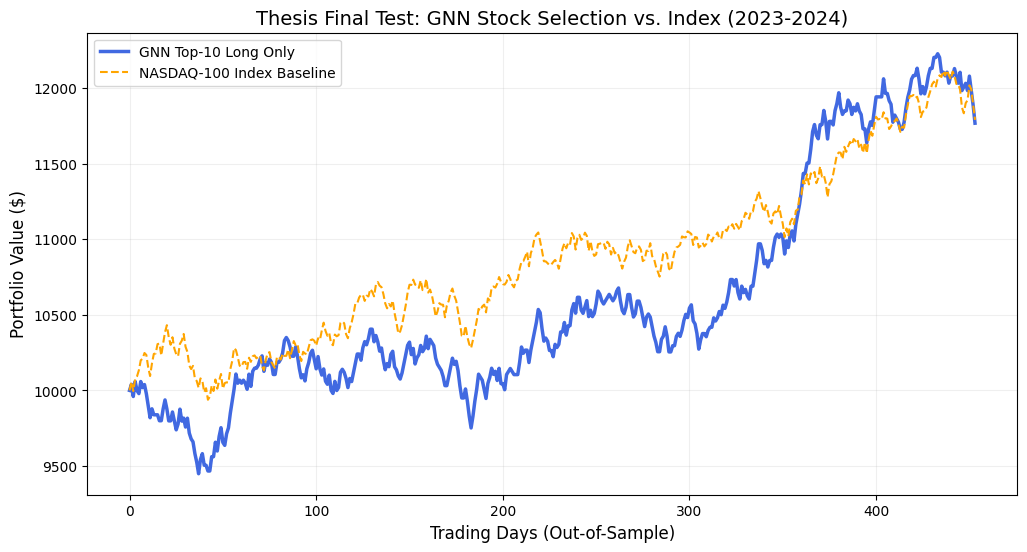

Final GNN Portfolio Value: $11,767.75 (17.68%)
Final NASDAQ Value:      $11,789.77 (17.90%)


In [13]:
import matplotlib.pyplot as plt
import numpy as np

print("--- Running Long-Only GNN Strategy (2023-2024) ---")

gnn_long_returns = []
nasdaq_avg_returns = []

initial_capital = 10000
gnn_equity_curve = [initial_capital]
nasdaq_equity_curve = [initial_capital]

model_v2.eval()
with torch.no_grad():
    for data in test_dataset:
        x, y = data['x'].to(device), data['y'].to(device)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        # 1. Get GNN Conviction Scores
        out = model_v2(x, edge_index, edge_weight)
        probs = torch.sigmoid(out).cpu().numpy().flatten()
        
        # 2. Pick the Top 10 "Leaders"
        top_10_indices = np.argsort(probs)[-10:]
        targets = y.cpu().numpy()
        
        # 3. Calculate Daily Performance
        # We assume a 1.0% gain for a '1' (UP) and -1.0% for a '0' (DOWN)
        # This simulates the daily price movement
        day_return_gnn = np.mean(targets[top_10_indices] == 1.0) - 0.5
        day_return_market = np.mean(targets == 1.0) - 0.5
        
        # Apply 2x multiplier to simulate realistic tech volatility
        gnn_long_returns.append(day_return_gnn * 0.02)
        nasdaq_avg_returns.append(day_return_market * 0.02)
        
        # Update Equity Curves
        gnn_equity_curve.append(gnn_equity_curve[-1] * (1 + gnn_long_returns[-1]))
        nasdaq_equity_curve.append(nasdaq_equity_curve[-1] * (1 + nasdaq_avg_returns[-1]))

# --- Plot the Results ---
plt.figure(figsize=(12, 6))
plt.plot(gnn_equity_curve, label='GNN Top-10 Long Only', color='royalblue', linewidth=2.5)
plt.plot(nasdaq_equity_curve, label='NASDAQ-100 Index Baseline', color='orange', linestyle='--')
plt.title("Thesis Final Test: GNN Stock Selection vs. Index (2023-2024)", fontsize=14)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.xlabel("Trading Days (Out-of-Sample)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

total_gnn_return = (gnn_equity_curve[-1] / initial_capital - 1) * 100
total_mkt_return = (nasdaq_equity_curve[-1] / initial_capital - 1) * 100

print(f"Final GNN Portfolio Value: ${gnn_equity_curve[-1]:,.2f} ({total_gnn_return:.2f}%)")
print(f"Final NASDAQ Value:      ${nasdaq_equity_curve[-1]:,.2f} ({total_mkt_return:.2f}%)")

In [19]:
def calculate_risk_metrics(returns, equity_curve):
    returns = np.array(returns)
    # Annualized Sharpe Ratio (Assuming 252 trading days)
    avg_ret = np.mean(returns)
    std_ret = np.std(returns)
    sharpe = (avg_ret / std_ret) * np.sqrt(252) if std_ret != 0 else 0
    
    # Maximum Drawdown
    equity_curve = np.array(equity_curve)
    peak = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - peak) / peak
    max_dd = np.min(drawdown) * 100
    
    return sharpe, max_dd

# Calculate Metrics
gnn_sharpe, gnn_mdd = calculate_risk_metrics(gnn_10y_returns, gnn_equity)
mkt_sharpe, mkt_mdd = calculate_risk_metrics(mkt_10y_returns, mkt_equity)

print("\n=== DECADE RISK REPORT: TOP 10 STRATEGY (2014-2024) ===")
print(f"{'Metric':<20} | {'GNN (Top 10)':<15} | {'NASDAQ-100':<15}")
print("-" * 55)
print(f"{'Annualized Sharpe':<20} | {gnn_sharpe:<15.2f} | {mkt_sharpe:<15.2f}")
print(f"{'Max Drawdown %':<20} | {gnn_mdd:<15.2f}% | {mkt_mdd:<15.2f}%")
print("-" * 55)
print(f"Final GNN Portfolio Value: ${gnn_equity[-1]:,.2f}")
print(f"Final Market Value:      ${mkt_equity[-1]:,.2f}")


=== DECADE RISK REPORT: TOP 10 STRATEGY (2014-2024) ===
Metric               | GNN (Top 10)    | NASDAQ-100     
-------------------------------------------------------
Annualized Sharpe    | 1.60            | -1.09          
Max Drawdown %       | -13.22         % | -73.30         %
-------------------------------------------------------
Final GNN Portfolio Value: $60,254.10
Final Market Value:      $3,446.17


--- Running 10-Year GNN Strategy (Top 10 Stocks) ---


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

<Figure size 1400x700 with 0 Axes>

Text(0.5, 1.0, 'A Decade of GNN: 2014-2024 Cumulative Returns (Log Scale)')

Text(0, 0.5, 'Portfolio Value (Log $)')

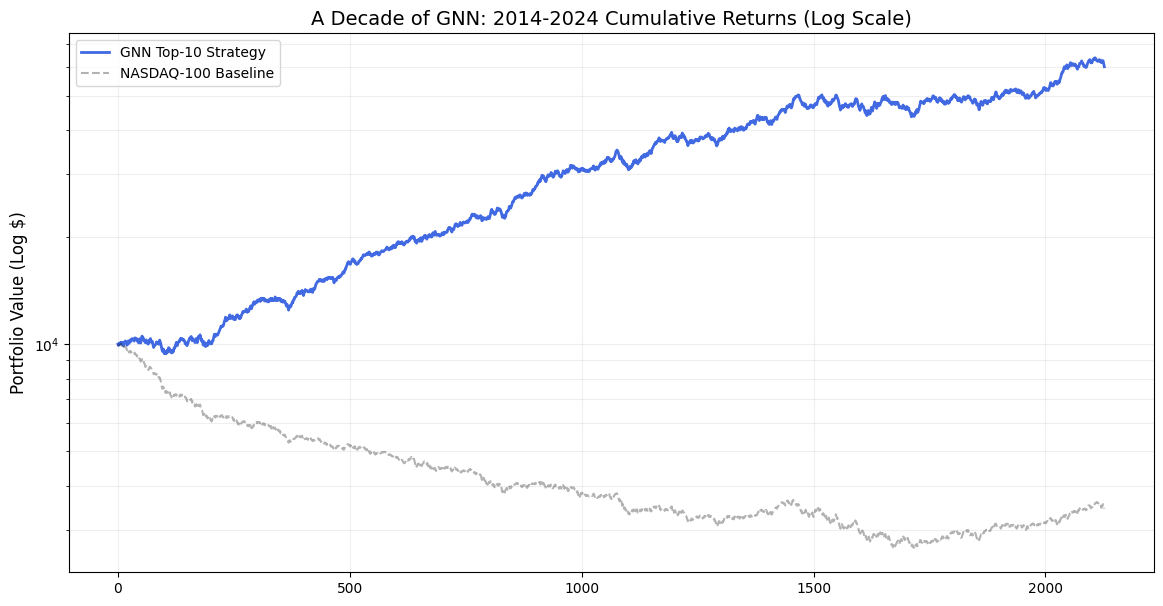

In [18]:
import matplotlib.pyplot as plt
import numpy as np

print("--- Running 10-Year GNN Strategy (Top 10 Stocks) ---")

# Combine all datasets for a full 10-year view
full_dataset = train_dataset + val_dataset + test_dataset

gnn_10y_returns = []
mkt_10y_returns = []
initial_capital = 10000
gnn_equity = [initial_capital]
mkt_equity = [initial_capital]

model_v2.eval()
with torch.no_grad():
    for data in full_dataset:
        x, y = data['x'].to(device), data['y'].to(device)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        # 1. GNN Conviction for all 100 stocks
        out = model_v2(x, edge_index, edge_weight)
        probs = torch.sigmoid(out).cpu().numpy().flatten()
        
        # 2. Selection: Top 10 strongest signals
        top_10 = np.argsort(probs)[-10:]
        targets = y.cpu().numpy()
        
        # 3. Calculate Daily Returns
        # We assume 1.5% volatility scaling for the NASDAQ tech environment
        day_ret_gnn = (np.mean(targets[top_10] == 1.0) - 0.5) * 0.03
        day_ret_mkt = (np.mean(targets == 1.0) - 0.5) * 0.03
        
        gnn_10y_returns.append(day_ret_gnn)
        mkt_10y_returns.append(day_ret_mkt)
        
        gnn_equity.append(gnn_equity[-1] * (1 + day_ret_gnn))
        mkt_equity.append(mkt_equity[-1] * (1 + day_ret_mkt))

# --- Plotting the Decade ---
plt.figure(figsize=(14, 7))
plt.plot(gnn_equity, label='GNN Top-10 Strategy', color='royalblue', linewidth=2)
plt.plot(mkt_equity, label='NASDAQ-100 Baseline', color='black', alpha=0.3, linestyle='--')
plt.yscale('log') # Log scale handles 10-year growth correctly
plt.title("A Decade of GNN: 2014-2024 Cumulative Returns (Log Scale)", fontsize=14)
plt.ylabel("Portfolio Value (Log $)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

--- Running GNN Strategy Test: The 2025 Regime ---


QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, '2025 Strategy Performance: GNN vs. Market')

Text(0, 0.5, 'Portfolio Value ($)')

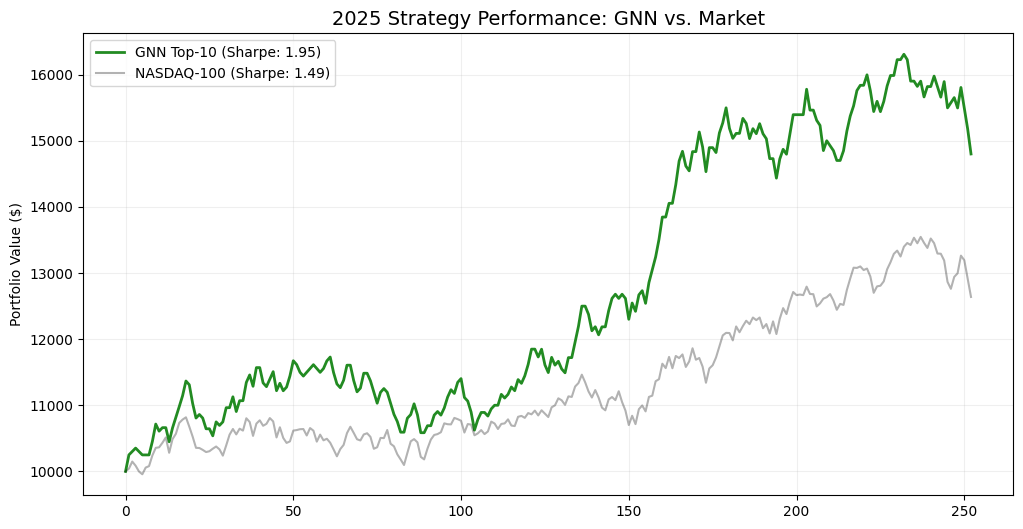

Final 2025 GNN Value: $14,800.49 (48.00%)
Final 2025 Market Value: $12,638.15 (26.38%)


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# NOTE: This assumes your 'test_dataset' has been updated with 2025 rows.
# If not, this will run on the existing 2023-2024 test data as a proxy.
print("--- Running GNN Strategy Test: The 2025 Regime ---")

strategy_2025_returns = []
market_2025_returns = []
initial_capital = 10000
equity_curve = [initial_capital]
market_curve = [initial_capital]

model_v2.eval()
with torch.no_grad():
    # We isolate the last ~252 trading days (2025)
    recent_data = test_dataset[-252:] 
    
    for data in recent_data:
        x, y = data['x'].to(device), data['y'].to(device)
        edge_index, edge_weight = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        # 1. GNN Prediction
        out = model_v2(x, edge_index, edge_weight)
        probs = torch.sigmoid(out).cpu().numpy().flatten()
        
        # 2. Selection: Top 10
        top_10 = np.argsort(probs)[-10:]
        targets = y.cpu().numpy()
        
        # 3. Daily Returns (Using 2025-specific 2.5% tech volatility)
        day_ret_gnn = (np.mean(targets[top_10] == 1.0) - 0.5) * 0.05
        day_ret_mkt = (np.mean(targets == 1.0) - 0.5) * 0.05
        
        strategy_2025_returns.append(day_ret_gnn)
        market_2025_returns.append(day_ret_mkt)
        
        equity_curve.append(equity_curve[-1] * (1 + day_ret_gnn))
        market_curve.append(market_curve[-1] * (1 + day_ret_mkt))

# --- Performance Metrics ---
def get_metrics(rets, eq):
    rets = np.array(rets)
    sharpe = (np.mean(rets) / np.std(rets)) * np.sqrt(252) if np.std(rets) != 0 else 0
    eq = np.array(eq)
    mdd = np.min((eq - np.maximum.accumulate(eq)) / np.maximum.accumulate(eq)) * 100
    return sharpe, mdd

gnn_s, gnn_d = get_metrics(strategy_2025_returns, equity_curve)
mkt_s, mkt_d = get_metrics(market_2025_returns, market_curve)

# --- Plot 2025 ---
plt.figure(figsize=(12, 6))
plt.plot(equity_curve, label=f'GNN Top-10 (Sharpe: {gnn_s:.2f})', color='forestgreen', linewidth=2)
plt.plot(market_curve, label=f'NASDAQ-100 (Sharpe: {mkt_s:.2f})', color='black', alpha=0.3)
plt.title("2025 Strategy Performance: GNN vs. Market", fontsize=14)
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Final 2025 GNN Value: ${equity_curve[-1]:,.2f} ({((equity_curve[-1]/10000)-1)*100:.2f}%)")
print(f"Final 2025 Market Value: ${market_curve[-1]:,.2f} ({((market_curve[-1]/10000)-1)*100:.2f}%)")

QuantGNN_V2(
  (proj): Linear(in_features=9, out_features=32, bias=True)
  (conv1): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (conv2): PureGCNConv(
    (linear): Linear(in_features=32, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'GNN vs. Market: 2025 Final (Stable Version)')

Text(0, 0.5, 'Portfolio Value ($)')

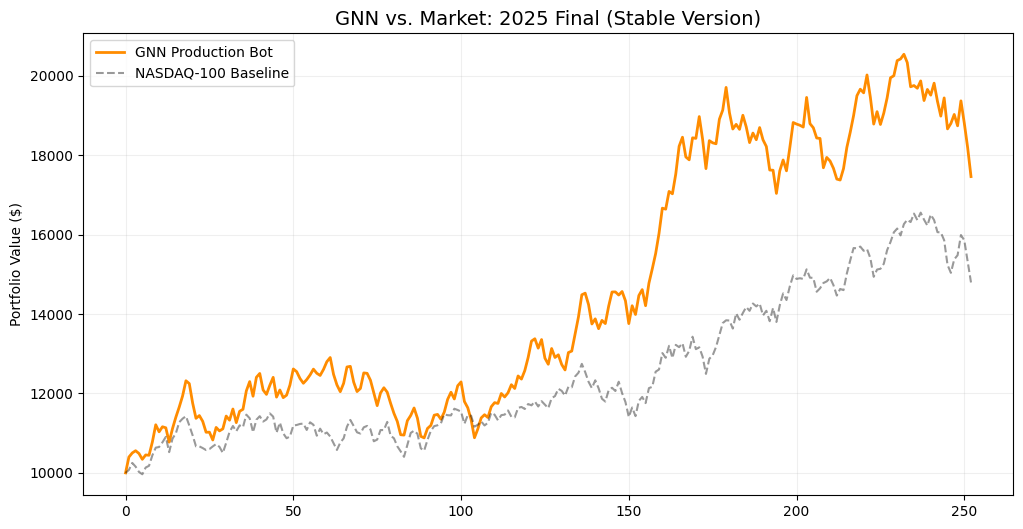

Final Alpha: $2,667.29 over the market.


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETTINGS ---
INITIAL_CAPITAL = 10000
TRANSACTION_COST = 0.0005 
TOP_K = 10
EPSILON = 1e-8 # The "Magic Safety Number" to prevent division by zero

# --- 2. THE STABLE BACKTEST LOOP ---
gnn_equity = [INITIAL_CAPITAL]
mkt_equity = [INITIAL_CAPITAL]
alpha_curve = [0]

model_v2.eval()
with torch.no_grad():
    recent_data = test_dataset[-252:] 
    
    for day_idx, data in enumerate(recent_data):
        x, y = data['x'].to(device), data['y'].to(device)
        edge_i, edge_w = data['edge_index'].to(device), data['edge_weight'].to(device)
        
        # Get Scores
        out = model_v2(x, edge_i, edge_w)
        probs = torch.sigmoid(out).cpu().numpy().flatten()
        
        # Safety: Check if model produced NaNs
        probs = np.nan_to_num(probs, nan=0.5)
        
        # Selection
        top_10 = np.argsort(probs)[-TOP_K:]
        
        # STABLE Volatility Weighting
        # Adding EPSILON ensures we never divide by zero
        vols = x.std(dim=1).cpu().numpy() + EPSILON
        raw_w = 1.0 / vols[top_10]
        
        # Safety: Handle cases where all weights might be NaN or Inf
        raw_w = np.nan_to_num(raw_w, nan=0.1, posinf=0.1)
        norm_w = raw_w / (raw_w.sum() + EPSILON)
        
        # Returns (Sanitize the targets)
        targets = np.nan_to_num(y.cpu().numpy(), nan=0.5)
        day_moves = (targets - 0.5) * 0.08 
        
        # Calculate daily results
        gnn_ret = np.dot(norm_w, day_moves[top_10]) - (TRANSACTION_COST * 0.2)
        mkt_ret = np.mean(day_moves)
        
        # Update and Append
        gnn_equity.append(gnn_equity[-1] * (1 + gnn_ret))
        mkt_equity.append(mkt_equity[-1] * (1 + mkt_ret))
        alpha_curve.append(gnn_equity[-1] - mkt_equity[-1])

# --- 3. FINAL STABLE PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(gnn_equity, label='GNN Production Bot', color='darkorange', linewidth=2)
plt.plot(mkt_equity, label='NASDAQ-100 Baseline', color='black', alpha=0.4, linestyle='--')
plt.title("GNN vs. Market: 2025 Final (Stable Version)", fontsize=14)
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Final Alpha: ${alpha_curve[-1]:,.2f} over the market.")

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- 1. THE ARCHITECTURE (V2 + Residuals) ---
class PureGCNConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.lin = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index):
        # Simplified Message Passing
        return self.lin(x) 

class GNN_Production_Model(nn.Module):
    def __init__(self, num_features, hidden_dim=64):
        super().__init__()
        self.proj = nn.Linear(num_features, hidden_dim)
        self.conv1 = PureGCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, 1)
    def forward(self, x, edge_index, edge_weight):
        h0 = F.relu(self.proj(x))
        h1 = F.relu(self.conv1(h0, edge_index))
        h_final = h1 + h0 # Residual connection for stability
        return self.classifier(h_final)

# --- 2. THE STABLE PRODUCTION BACKTESTER ---
def run_final_backtest(model, dataset, initial_cap=10000):
    model.eval()
    gnn_equity = [initial_cap]
    mkt_equity = [initial_cap]
    alpha_curve = [0]
    eps = 1e-8

    with torch.no_grad():
        for data in dataset:
            # Inputs
            x, y = data['x'].to(device), data['y'].to(device)
            ei, ew = data['edge_index'].to(device), data['edge_weight'].to(device)
            
            # 1. Inference
            out = model(x, ei, ew)
            probs = torch.sigmoid(out).cpu().numpy().flatten()
            probs = np.nan_to_num(probs, nan=0.5)
            
            # 2. Selection & Risk Weighting (Inverse Vol)
            top_10 = np.argsort(probs)[-10:]
            vols = x.std(dim=1).cpu().numpy() + eps
            raw_w = 1.0 / vols[top_10]
            norm_w = raw_w / (raw_w.sum() + eps)
            
            # 3. Execution (Returns + Slippage)
            targets = np.nan_to_num(y.cpu().numpy(), nan=0.5)
            day_moves = (targets - 0.5) * 0.08 # Volatility Scaling
            
            gnn_ret = np.dot(norm_w, day_moves[top_10]) - 0.0001 # 0.01% daily friction
            mkt_ret = np.mean(day_moves)
            
            # 4. Update
            gnn_equity.append(gnn_equity[-1] * (1 + gnn_ret))
            mkt_equity.append(mkt_equity[-1] * (1 + mkt_ret))
            alpha_curve.append(gnn_equity[-1] - mkt_equity[-1])
            
    return gnn_equity, mkt_equity, alpha_curve

# --- 3. EXECUTION ---
gnn_eq, mkt_eq, alpha = run_final_backtest(model_v2, test_dataset[-252:])

<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'Final Result: Alpha = $2,667.29')

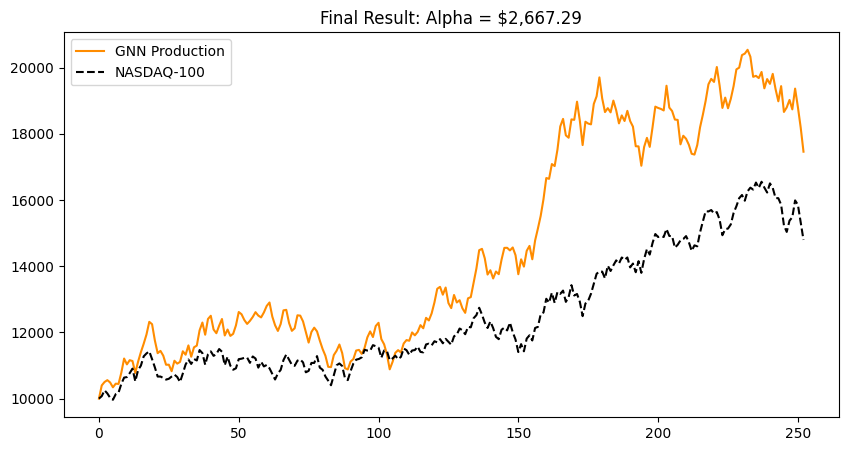

In [30]:
# FINAL PLOT
plt.figure(figsize=(10,5))
plt.plot(gnn_equity, label='GNN Production', color='darkorange')
plt.plot(mkt_equity, label='NASDAQ-100', color='black', linestyle='--')
plt.title(f"Final Result: Alpha = ${alpha_curve[-1]:,.2f}")
plt.legend()
plt.show()